# 02 — Baseline Models (Step 3 & 4)
10 classifiers | seed=42 | split 70/30 | k-fold k=5

Metrics: Accuracy, Precision, Recall, F1-Score, AUC (OvR weighted)

In [1]:
import sys; sys.path.append('../src')
from pathlib import Path
import pandas as pd
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold

from models   import get_baseline_models
from evaluate import train_and_evaluate, find_top2
from utils    import (save_model, plot_all_confusion_matrices, plot_roc_curves, plot_metrics_comparison)

SEED = 42
BASELINE_DIR = Path('../results/baseline')
FIG_DIR = Path('../results/figures')
MODEL_DIR = Path('../models/baseline')
for p in [BASELINE_DIR, FIG_DIR / 'eda_plots', FIG_DIR / 'confusion_matrix', FIG_DIR / 'roc_curves', MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Dữ liệu đã làm sạch, CHƯA scale. Việc scale sẽ nằm trong Pipeline của từng model.
df = pd.read_csv('../data/processed/thyroid_processed.csv')
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Class dist train:\n{y_train.value_counts().sort_index()}')
print(f'Class dist test:\n{y_test.value_counts().sort_index()}')


Train: (150, 5) | Test: (65, 5)
Class dist train:
class
1    105
2     24
3     21
Name: count, dtype: int64
Class dist test:
class
1    45
2    11
3     9
Name: count, dtype: int64


## Train & Evaluate tất cả 10 models

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
models = get_baseline_models()

df_metrics = train_and_evaluate(models, X_train, y_train, X_test, y_test, cv=cv)

df_metrics.to_csv(BASELINE_DIR / 'metrics_table.csv', index=False)
df_metrics[['Model','Time(s)']].to_csv(BASELINE_DIR / 'execution_time.csv', index=False)

print('\n=== BẢNG KẾT QUẢ ===')
df_metrics


01_kNN                          cv_f1=0.91  test_f1=0.95  auc=1.00  time=0.0023s
02_NaiveBayes                   cv_f1=0.95  test_f1=0.98  auc=1.00  time=0.0021s
03_SVM                          cv_f1=0.93  test_f1=0.97  auc=1.00  time=0.004s
04_DecisionTree                 cv_f1=0.90  test_f1=0.95  auc=0.93  time=0.0018s
05_RandomForest                 cv_f1=0.94  test_f1=0.98  auc=1.00  time=0.0994s
06_AdaBoost                     cv_f1=0.93  test_f1=0.95  auc=0.99  time=0.0542s
07_GradientBoosting             cv_f1=0.94  test_f1=0.97  auc=1.00  time=0.2125s
08_LDA                          cv_f1=0.90  test_f1=0.90  auc=1.00  time=0.0024s
09_MLP                          cv_f1=0.93  test_f1=0.98  auc=1.00  time=0.3708s
10_LogisticRegression           cv_f1=0.93  test_f1=0.98  auc=1.00  time=0.0076s

=== BẢNG KẾT QUẢ ===


,Model,CV Accuracy,CV Precision,CV Recall,CV F1-Score,CV AUC,Accuracy,Precision,Recall,F1-Score,AUC,Time(s)
0,kNN,0.92,0.93,0.92,0.91,0.95,0.95,0.96,0.95,0.95,1.00,0.0023
1,NaiveBayes,0.96,0.96,0.96,0.95,1.00,0.98,0.98,0.98,0.98,1.00,0.0021
2,SVM,0.93,0.94,0.93,0.93,0.99,0.97,0.97,0.97,0.97,1.00,0.0040
3,DecisionTree,0.91,0.92,0.91,0.90,0.89,0.95,0.96,0.95,0.95,0.93,0.0018
4,RandomForest,0.95,0.95,0.95,0.94,0.99,0.98,0.98,0.98,0.98,1.00,0.0994
5,AdaBoost,0.94,0.95,0.94,0.93,0.99,0.95,0.96,0.95,0.95,0.99,0.0542
6,GradientBoosting,0.94,0.94,0.94,0.94,0.99,0.97,0.97,0.97,0.97,1.00,0.2125
7,LDA,0.91,0.92,0.91,0.90,0.98,0.91,0.92,0.91,0.90,1.00,0.0024
8,MLP,0.93,0.94,0.93,0.93,0.98,0.98,0.99,0.98,0.98,1.00,0.3708
9,LogisticRegression,0.94,0.94,0.94,0.93,0.99,0.98,0.98,0.98,0.98,1.00,0.0076


## Top 2 theo từng metric (Step 4)

In [3]:
find_top2(df_metrics)


Top 2 — Accuracy:
       Model  Accuracy
  NaiveBayes      0.98
RandomForest      0.98

Top 2 — Precision:
     Model  Precision
       MLP       0.99
NaiveBayes       0.98

Top 2 — Recall:
       Model  Recall
  NaiveBayes    0.98
RandomForest    0.98

Top 2 — F1-Score:
       Model  F1-Score
  NaiveBayes      0.98
RandomForest      0.98

Top 2 — AUC:
     Model  AUC
       kNN  1.0
NaiveBayes  1.0


## Biểu đồ so sánh metrics

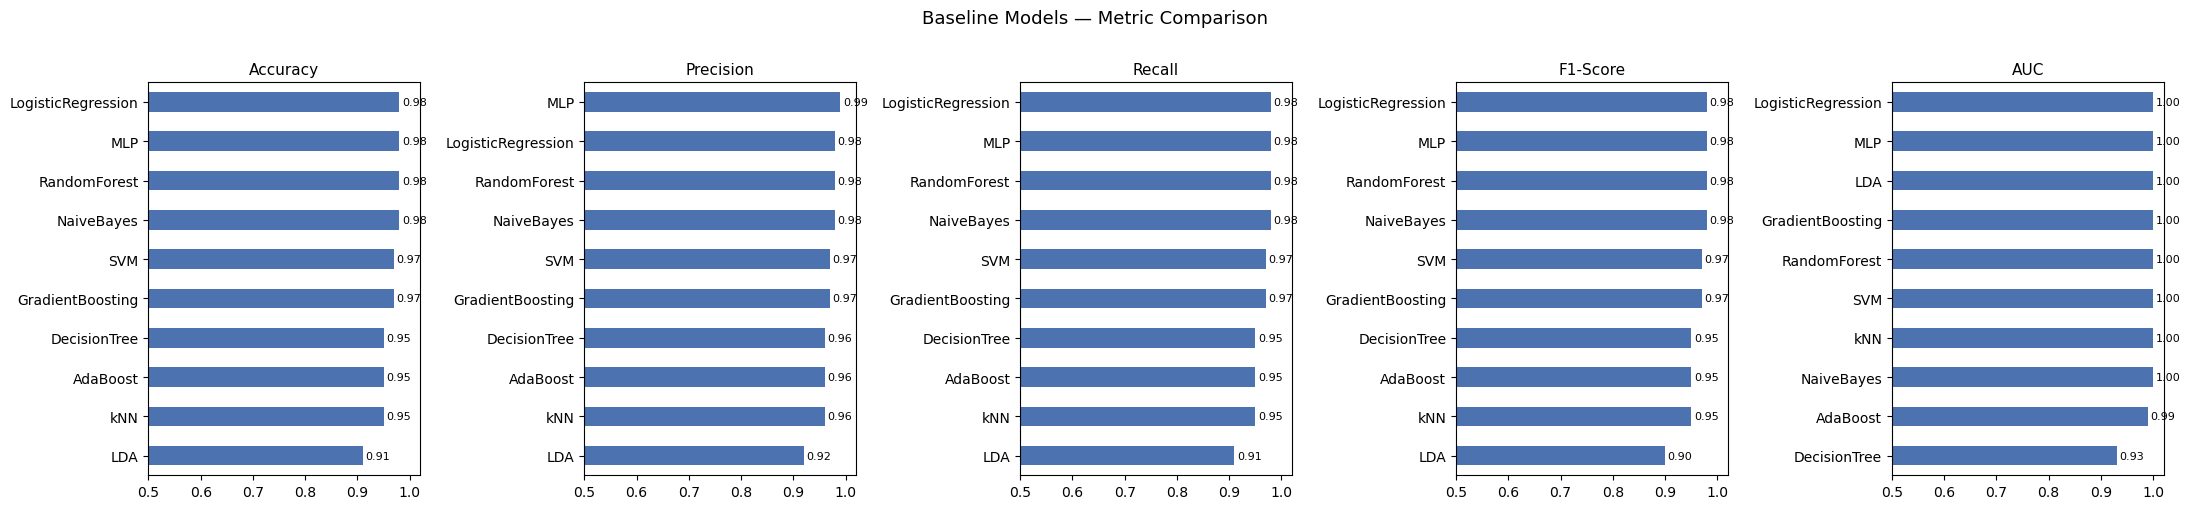

In [4]:
plot_metrics_comparison(df_metrics, save_path=FIG_DIR / 'eda_plots' / 'metrics_comparison.png')


## Confusion Matrix — tất cả models

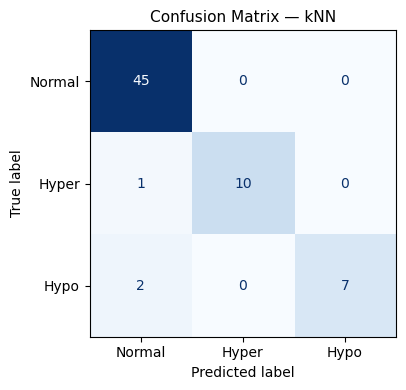

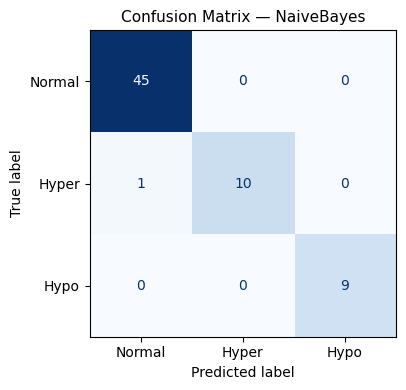

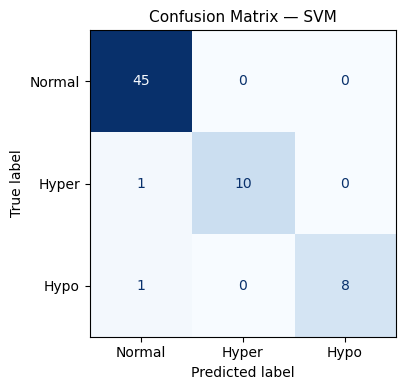

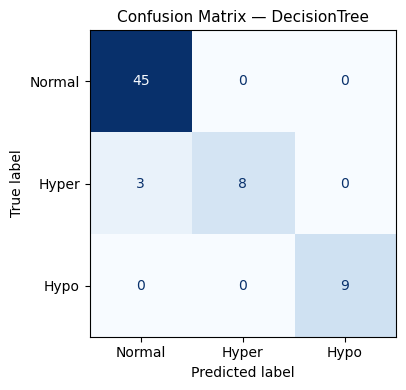

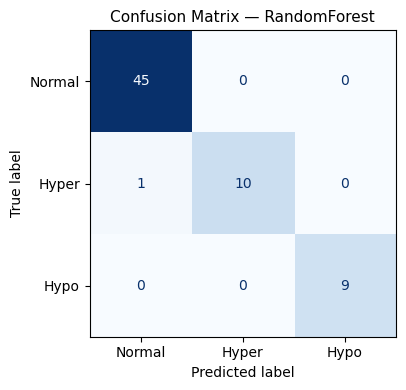

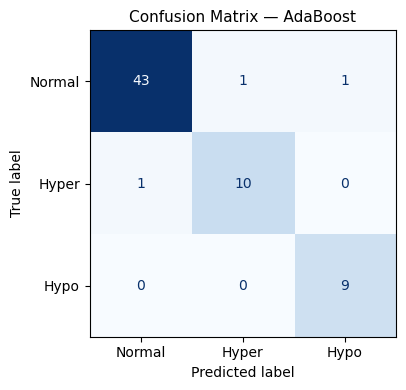

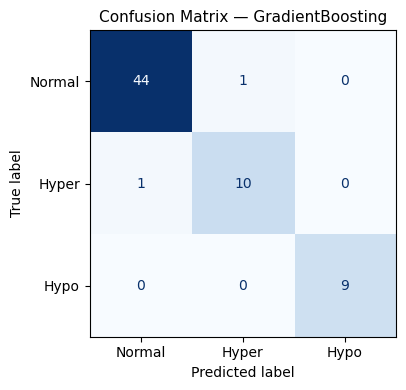

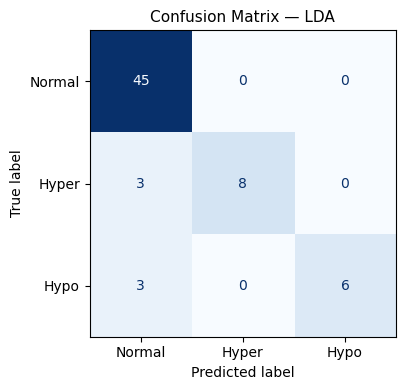

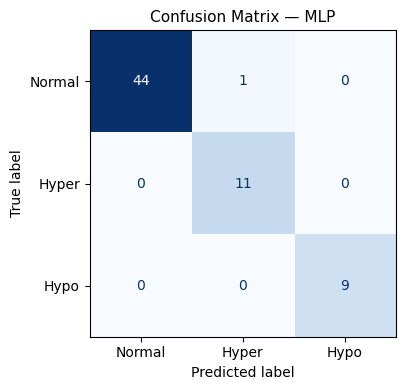

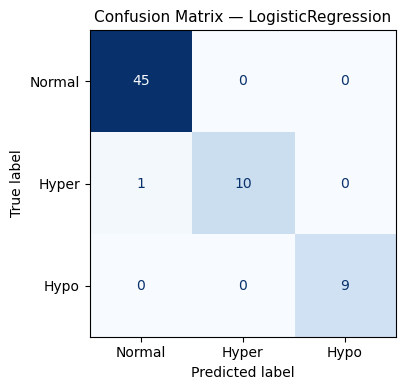

In [5]:
plot_all_confusion_matrices(models, X_test, y_test, save_dir=FIG_DIR / 'confusion_matrix')


## ROC Curves — top 3 models

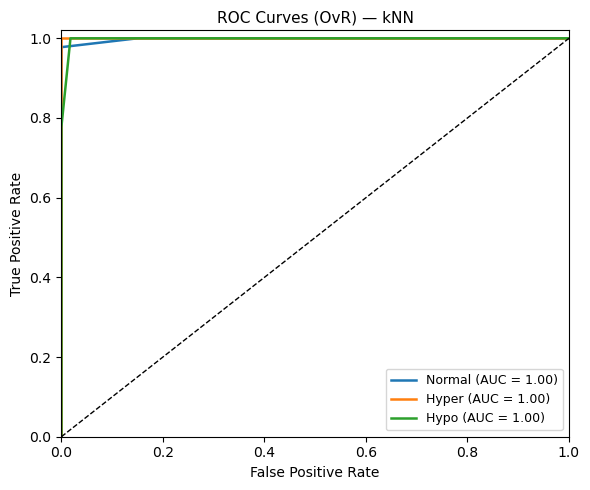

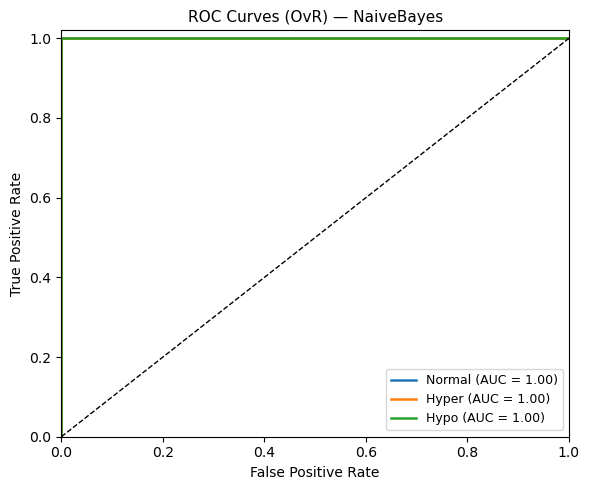

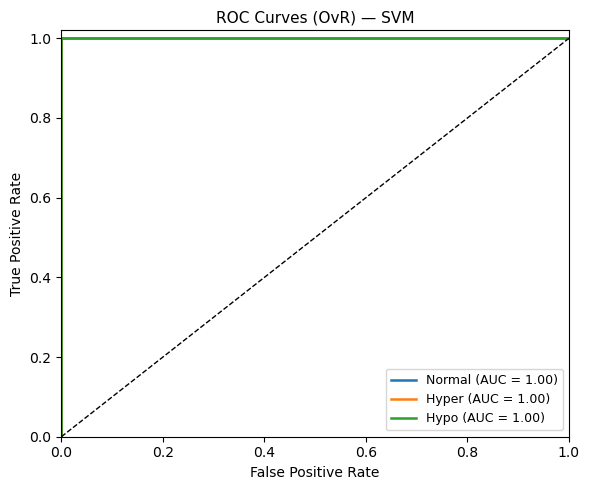

In [6]:
top3_names = df_metrics.nlargest(3, 'AUC')['Model'].tolist()
for name, model in models.items():
    short = name.split('_',1)[1]
    if short in top3_names:
        plot_roc_curves(model, X_test, y_test, short, save_dir=FIG_DIR / 'roc_curves')


## Lưu tất cả 10 models (.pkl)

In [8]:
for name, model in models.items():
    save_model(model, name, MODEL_DIR)


Saved → ..\models\baseline\01_kNN.pkl
Saved → ..\models\baseline\02_NaiveBayes.pkl
Saved → ..\models\baseline\03_SVM.pkl
Saved → ..\models\baseline\04_DecisionTree.pkl
Saved → ..\models\baseline\05_RandomForest.pkl
Saved → ..\models\baseline\06_AdaBoost.pkl
Saved → ..\models\baseline\07_GradientBoosting.pkl
Saved → ..\models\baseline\08_LDA.pkl
Saved → ..\models\baseline\09_MLP.pkl
Saved → ..\models\baseline\10_LogisticRegression.pkl
